# Part A :- Concept Application

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [3]:
# Load Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame

In [4]:
# Add species names
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Expand dataset to 600 rows
df = pd.concat([df] * 4, ignore_index=True)

print("Dataset shape:", df.shape)

Dataset shape: (600, 6)


## 1. Data Selection using loc

In [5]:
print("\nloc Example 1")
print(df.loc[0:4, ['sepal length (cm)', 'species']])

print("\nloc Example 2")
print(df.loc[10:15, ['petal length (cm)', 'petal width (cm)']])

print("\nloc Example 3")
print(df.loc[25, ['sepal width (cm)', 'species']])


loc Example 1
   sepal length (cm) species
0                5.1  setosa
1                4.9  setosa
2                4.7  setosa
3                4.6  setosa
4                5.0  setosa

loc Example 2
    petal length (cm)  petal width (cm)
10                1.5               0.2
11                1.6               0.2
12                1.4               0.1
13                1.1               0.1
14                1.2               0.2
15                1.5               0.4

loc Example 3
sepal width (cm)       3.0
species             setosa
Name: 25, dtype: object


## 2. Data Selection using iloc

In [6]:
print("\niloc Example 1")
print(df.iloc[0:5, 0:3])

print("\niloc Example 2")
print(df.iloc[20:30, 1:4])

print("\niloc Example 3")
print(df.iloc[50, 0:5])


iloc Example 1
   sepal length (cm)  sepal width (cm)  petal length (cm)
0                5.1               3.5                1.4
1                4.9               3.0                1.4
2                4.7               3.2                1.3
3                4.6               3.1                1.5
4                5.0               3.6                1.4

iloc Example 2
    sepal width (cm)  petal length (cm)  petal width (cm)
20               3.4                1.7               0.2
21               3.7                1.5               0.4
22               3.6                1.0               0.2
23               3.3                1.7               0.5
24               3.4                1.9               0.2
25               3.0                1.6               0.2
26               3.4                1.6               0.4
27               3.5                1.5               0.2
28               3.4                1.4               0.2
29               3.2                1.6 

## 3. Filtering Data

In [7]:
filtered = df[
    (df['sepal length (cm)'] > 6) &
    (df['species'] == 'virginica')
]

print("\nFiltered Data")
print(filtered.head())


Filtered Data
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
100                6.3               3.3                6.0               2.5   
102                7.1               3.0                5.9               2.1   
103                6.3               2.9                5.6               1.8   
104                6.5               3.0                5.8               2.2   
105                7.6               3.0                6.6               2.1   

     target    species  
100       2  virginica  
102       2  virginica  
103       2  virginica  
104       2  virginica  
105       2  virginica  


## 4. Descriptive Statistics

In [8]:

print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         600.000000        600.000000         600.000000   
mean            5.843333          3.057333           3.758000   
std             0.825990          0.434773           1.760872   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        600.000000  600.000000  
mean           1.199333    1.000000  
std            0.760326    0.817178  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


## 5. Histogram

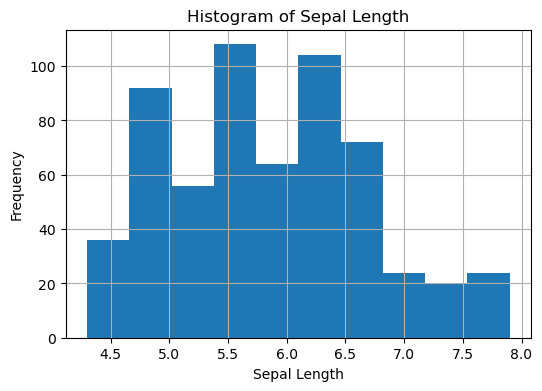

In [9]:
plt.figure(figsize=(6,4))
df['sepal length (cm)'].hist()
plt.title("Histogram of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()


## 6. Bar Plot

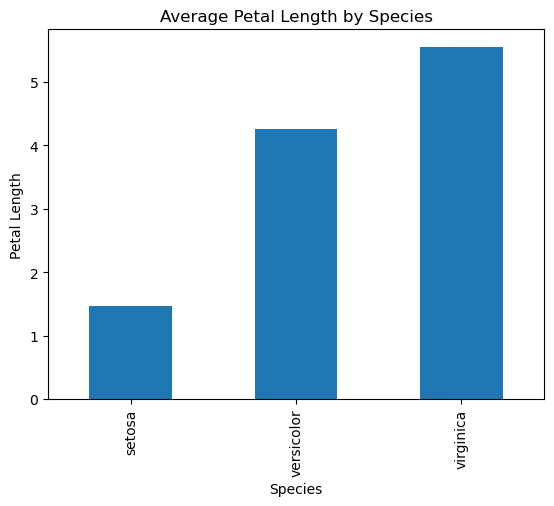

In [10]:

df.groupby('species')['petal length (cm)'].mean().plot(kind='bar')

plt.title("Average Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length")
plt.show()

## 7. Line Chart

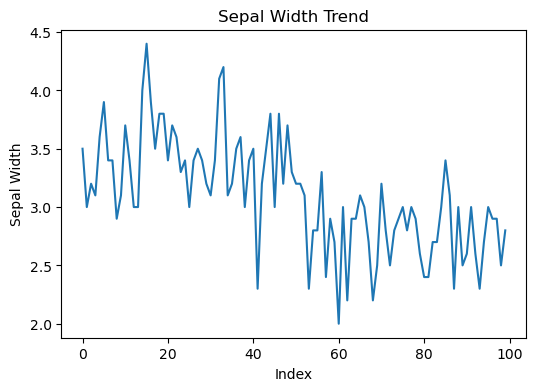

In [11]:
plt.figure(figsize=(6,4))
plt.plot(df.index[:100], df['sepal width (cm)'][:100])

plt.title("Sepal Width Trend")
plt.xlabel("Index")
plt.ylabel("Sepal Width")
plt.show()

## 8. KDE Plot

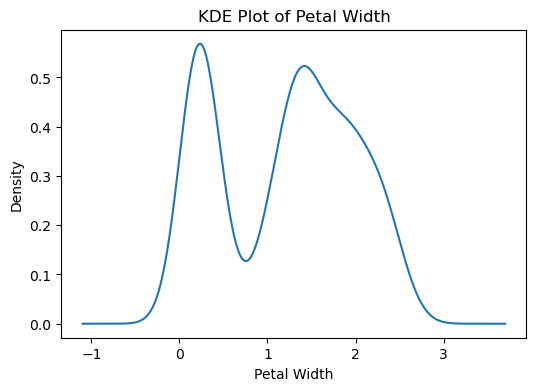

In [12]:
plt.figure(figsize=(6,4))
df['petal width (cm)'].plot(kind='kde')

plt.title("KDE Plot of Petal Width")
plt.xlabel("Petal Width")
plt.show()

# Part B :- Stretch Problem

## 1. Grouped analysis

In [13]:
grouped = df.groupby("species").mean()

print("Grouped Mean Values:")
print(grouped)

Grouped Mean Values:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  target  
species                               
setosa                 0.246     0.0  
versicolor             1.326     1.0  
virginica              2.026     2.0  


## 2. Bar plot for grouped results

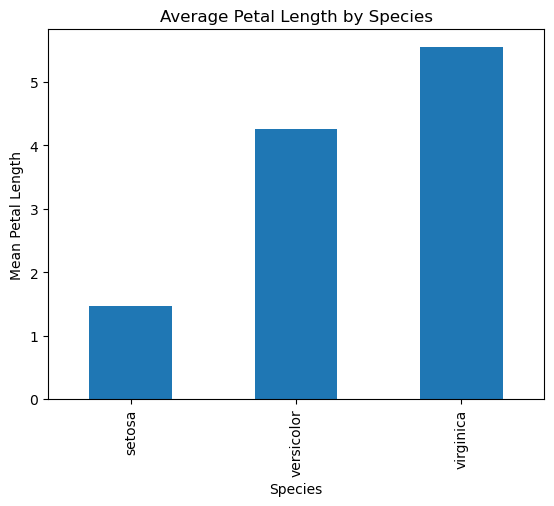

In [14]:
grouped["petal length (cm)"].plot(kind="bar")
plt.title("Average Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Mean Petal Length")
plt.show()


## 3. Compare two numerical features using line chart

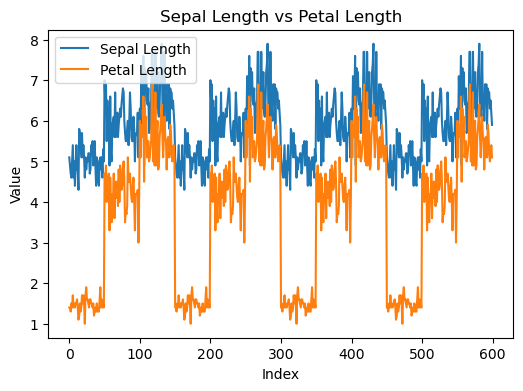

In [15]:
plt.figure(figsize=(6,4))

plt.plot(df.index, df["sepal length (cm)"], label="Sepal Length")
plt.plot(df.index, df["petal length (cm)"], label="Petal Length")

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.show()

## 4. KDE plot comparison

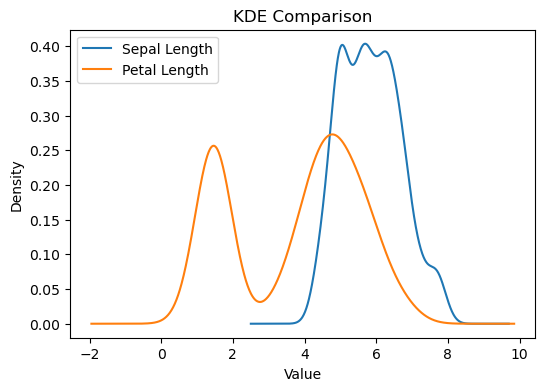

In [16]:
plt.figure(figsize=(6,4))

df["sepal length (cm)"].plot(kind="kde", label="Sepal Length")
df["petal length (cm)"].plot(kind="kde", label="Petal Length")

plt.title("KDE Comparison")
plt.xlabel("Value")
plt.legend()
plt.show()